In [1]:
import os
import numpy as np
import pandas as pd
import gc
import time
from contextlib import contextmanager
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import zipfile 
from pathlib import Path

import missingno as msno
import pickle

In [2]:
installments_payments = pd.read_csv("data/installments_payments.csv")
print('Installments payments data shape: ', installments_payments.shape)
installments_payments.head()

Installments payments data shape:  (13605401, 8)


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


# Vue graphique des Nan

<Axes: >

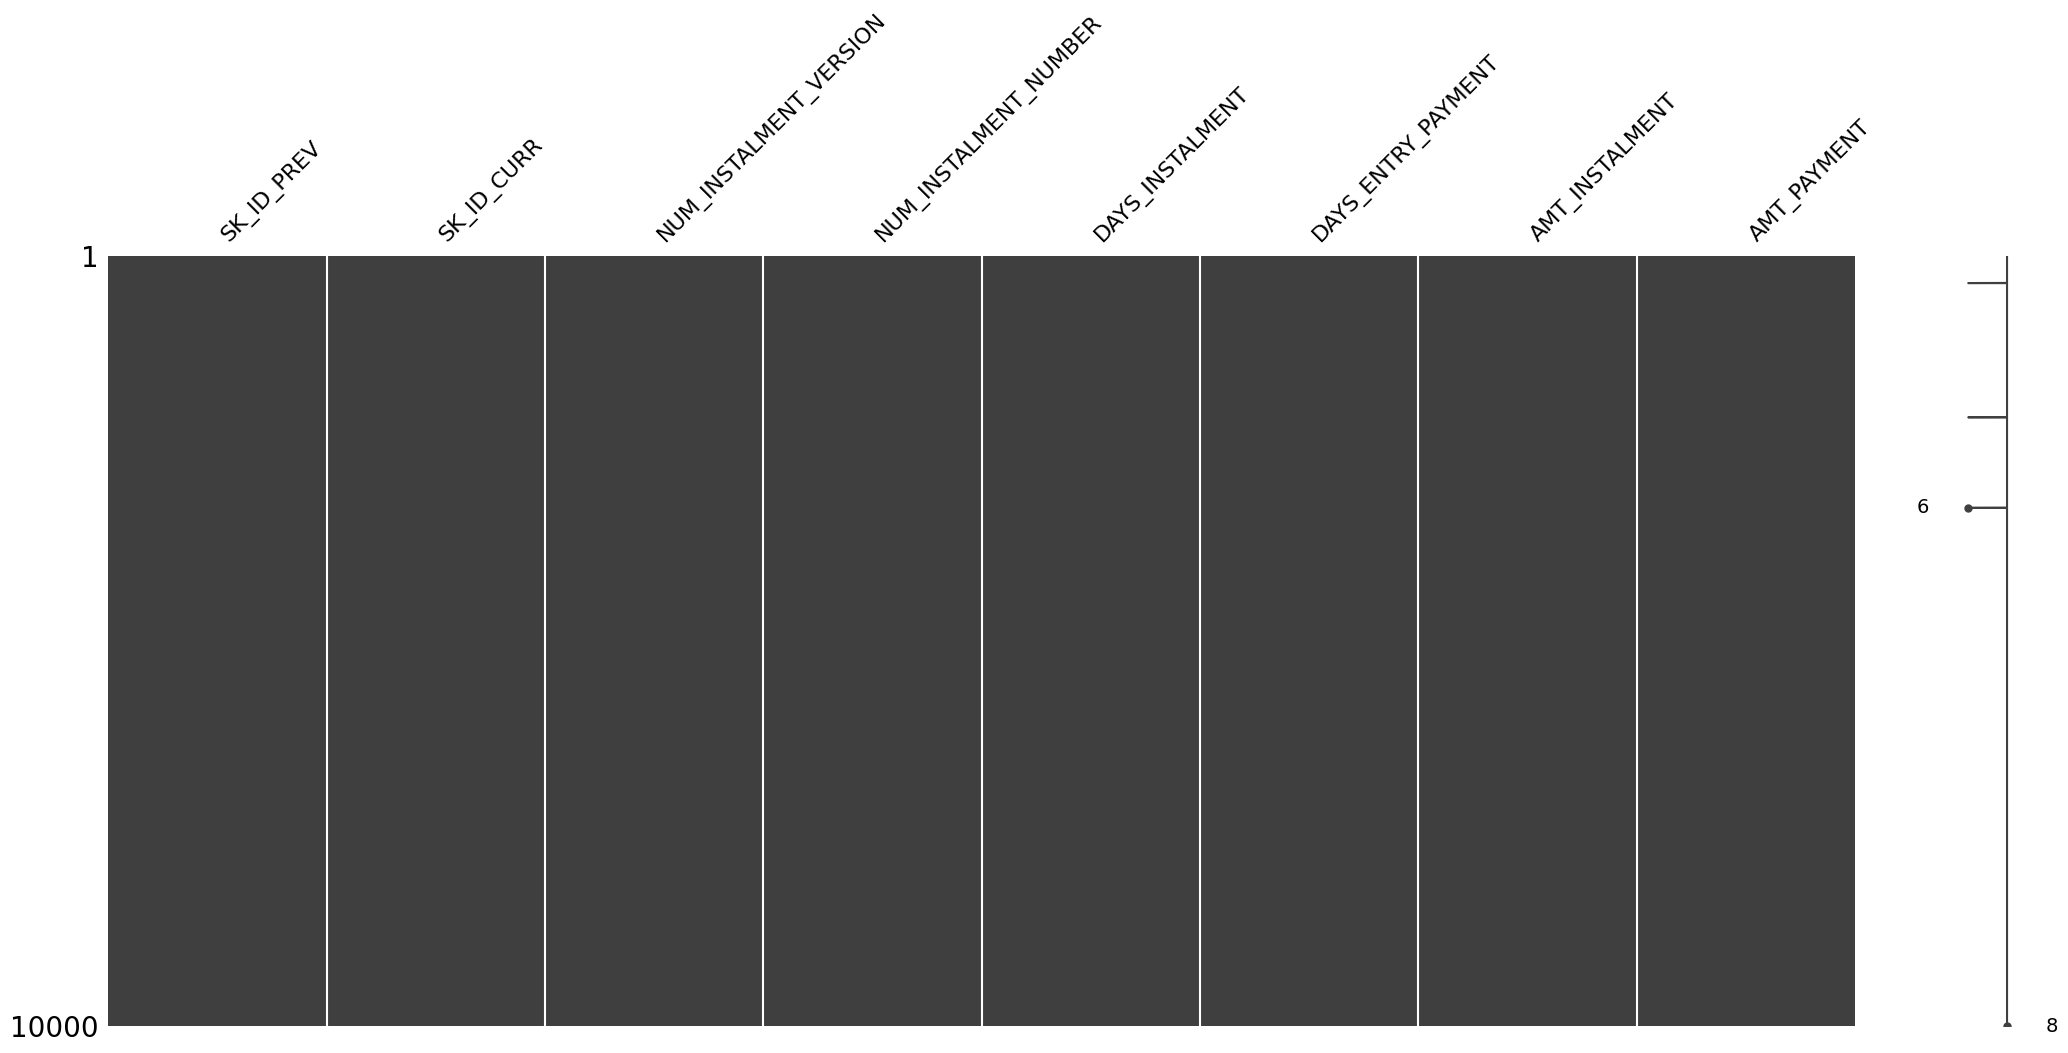

In [3]:
%matplotlib inline
msno.matrix(installments_payments.sample(10000))

# recherche de doublons

In [4]:
installments_payments.duplicated();

# Vérifier les NaN mathematiquement

In [5]:
print(installments_payments.isnull().sum())
print("\nPourcentage de NaN par colonne :")

SK_ID_PREV                   0
SK_ID_CURR                   0
NUM_INSTALMENT_VERSION       0
NUM_INSTALMENT_NUMBER        0
DAYS_INSTALMENT              0
DAYS_ENTRY_PAYMENT        2905
AMT_INSTALMENT               0
AMT_PAYMENT               2905
dtype: int64

Pourcentage de NaN par colonne :


In [6]:
installments_payments.isnull().mean() * 100;

# on regarde si des colonnes sont des objets
# output ci-dessous: pas de colonne objet, pas d'encodage.

In [7]:
installments_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


# traitement des NaN (que des colonnes integer ou float=>mediane)

In [8]:
num_cols = installments_payments.select_dtypes(exclude='object').columns

installments_payments[num_cols] = installments_payments[num_cols].fillna(installments_payments[num_cols].median())

# solde de NaN

In [9]:
print("NaN restants :", installments_payments.isnull().sum().sum())

NaN restants : 0


In [10]:
installments_payments[ 'NUM_INSTALMENT_VERSION'].unique();

In [11]:
installments_payments[ 'NUM_INSTALMENT_NUMBER'].unique();

# jour de l'échéance du paiement

In [12]:
installments_payments[ 'DAYS_INSTALMENT'].unique();

# jour du paiement

In [13]:
installments_payments[ 'DAYS_ENTRY_PAYMENT'].unique();

# montant de l'échéance

In [14]:
installments_payments[ 'AMT_INSTALMENT'].unique();

# montant du paiement

In [15]:
installments_payments[ 'AMT_PAYMENT'].unique();

# Vérifier les colonnes non-numériques

In [16]:
print(installments_payments.select_dtypes(exclude=['number']).columns)

Index([], dtype='object')


# Suppression colonnes sans intérêt (num_installments_version et number quand le credit est renégocié et le rang de l'échéance,...; )

In [17]:
installments_payments.drop(columns=['NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER'], inplace=True)

# FEATURES MÉTIER

In [18]:
# Retard de paiement (en jours): paiement en retard si DAYS_LATE >0
installments_payments['DAYS_LATE'] = installments_payments['DAYS_ENTRY_PAYMENT'] - installments_payments['DAYS_INSTALMENT']

# Différence de montant (impayé ou surpayé)
installments_payments['AMT_DIFF'] = installments_payments['AMT_INSTALMENT'] - installments_payments['AMT_PAYMENT']

# Indicateurs binaires
installments_payments['IS_LATE'] = (installments_payments['DAYS_LATE'] > 0).astype(int)
installments_payments['IS_UNDERPAID'] = (installments_payments['AMT_DIFF'] > 0).astype(int)



# AGRÉGATION PAR CRÉDIT (SK_ID_PREV)

In [19]:
installments_agg = installments_payments.groupby('SK_ID_PREV').agg({
    # Montants
    'AMT_PAYMENT': ['mean', 'sum', 'max'],
    'AMT_INSTALMENT': ['mean', 'sum', 'max'],
    'AMT_DIFF': ['mean', 'sum', 'max', 'min'],  # Impayés
    
    # Retards
    'DAYS_LATE': ['mean', 'max', 'min'],  # Moyenne et max de retard
    'IS_LATE': ['sum', 'mean'],  # Nombre et % de paiements en retard
    
    # Sous-paiements
    'IS_UNDERPAID': ['sum', 'mean'],  # Nombre et % de sous-paiements

        
    # Dates
    'DAYS_INSTALMENT': ['min', 'max'],  # Ancienneté du crédit
    'DAYS_ENTRY_PAYMENT': ['min', 'max']
})

In [20]:
# Renommer les colonnes
installments_agg.columns = ['INSTAL_' + '_'.join(col).upper() for col in installments_agg.columns]

# Ajouter le nombre total d'échéances
installments_agg['INSTAL_COUNT'] = installments_payments.groupby('SK_ID_CURR').size()

installments_agg.reset_index(inplace=True)

print(f" installments_agg shape: {installments_agg.shape}")
print(f"   Colonnes clés: {installments_agg.columns[:5].tolist()} ...")
print(f"   SK_ID_PREV présent: {'SK_ID_PREV' in installments_agg.columns}")

 installments_agg shape: (997752, 23)
   Colonnes clés: ['SK_ID_PREV', 'INSTAL_AMT_PAYMENT_MEAN', 'INSTAL_AMT_PAYMENT_SUM', 'INSTAL_AMT_PAYMENT_MAX', 'INSTAL_AMT_INSTALMENT_MEAN'] ...
   SK_ID_PREV présent: True


In [21]:
installments_agg.columns.tolist()

['SK_ID_PREV',
 'INSTAL_AMT_PAYMENT_MEAN',
 'INSTAL_AMT_PAYMENT_SUM',
 'INSTAL_AMT_PAYMENT_MAX',
 'INSTAL_AMT_INSTALMENT_MEAN',
 'INSTAL_AMT_INSTALMENT_SUM',
 'INSTAL_AMT_INSTALMENT_MAX',
 'INSTAL_AMT_DIFF_MEAN',
 'INSTAL_AMT_DIFF_SUM',
 'INSTAL_AMT_DIFF_MAX',
 'INSTAL_AMT_DIFF_MIN',
 'INSTAL_DAYS_LATE_MEAN',
 'INSTAL_DAYS_LATE_MAX',
 'INSTAL_DAYS_LATE_MIN',
 'INSTAL_IS_LATE_SUM',
 'INSTAL_IS_LATE_MEAN',
 'INSTAL_IS_UNDERPAID_SUM',
 'INSTAL_IS_UNDERPAID_MEAN',
 'INSTAL_DAYS_INSTALMENT_MIN',
 'INSTAL_DAYS_INSTALMENT_MAX',
 'INSTAL_DAYS_ENTRY_PAYMENT_MIN',
 'INSTAL_DAYS_ENTRY_PAYMENT_MAX',
 'INSTAL_COUNT']

# utilisation de pickle pour rappler l'objet plus tard

In [22]:
with open('installments_agg.pkl', 'wb') as f:
    pickle.dump(installments_agg, f)